In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import mlacca_functions as mlcf
import os

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import NearestCentroid
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

from warnings import filterwarnings
filterwarnings("ignore", module="sklearn", category=UserWarning)

In [2]:
csv_folder = 'data\\csv_files'
clf_folder = 'data\\models'
ru_test_file = f'{csv_folder}\\big_benchmark\\ru_test.csv'

In [3]:
ru_test_df = pd.read_csv(ru_test_file)
print(f'\nShannon diversity index: {mlcf.Shannon_diversity_index(ru_test_df["category"])}')


Shannon diversity index: 0.9840598958468987


In [4]:
def get_formulae(df:pd.DataFrame) -> list[str]:
    '''
    Constructs a list of molecular formulae from the elemental composition columns in the dataframe.
    Parameters:

    df:
        A pandas DataFrame containing columns 'C', 'H', 'O', 'N', 'P', 'S' representing the counts of each element in the molecule.
    
    Returns:
        A list of strings, where each string is a molecular formula in the format 'C{c}H{h}O{o}N{n}P{p}S{s}'.
    '''
    return [f'C{c}H{h}O{o}N{n}P{p}S{s}' for c, h, o, n, p, s in df[['C', 'H', 'O', 'N', 'P', 'S']].to_numpy()]

In [5]:
clf_training_df_path = f'{csv_folder}\\new_vk_areas_df.csv'
clf_training_df = pd.read_csv(clf_training_df_path)

ru_test_formulae = get_formulae(ru_test_df)
clf_training_formulae = get_formulae(clf_training_df)

same_formulae_idx = [i for i, formula in enumerate(ru_test_formulae) if formula in clf_training_formulae]
print(f'Number of formulae matching between the datasets: {len(same_formulae_idx)}')

Number of formulae matching between the datasets: 692


In [6]:
ru_test_df_cropped = ru_test_df.drop(index=same_formulae_idx).reset_index(drop=True)
categories = ru_test_df_cropped['category'].unique()
class_weights_ru = compute_class_weight('balanced', classes=categories, y=ru_test_df_cropped['category'])
weights_dict_ru = {cls: weight for cls, weight in zip(categories, class_weights_ru)}
weights_ru = [weights_dict_ru[cat] for cat in ru_test_df_cropped['category']]

In [7]:
# MSCC
y_pred_ru = mlcf.molecclass(ru_test_df_cropped,mlcf.rivasubach_areas,['O/C','H/C','N/C'])
y_pred_ru_complete = mlcf.molecclass(ru_test_df_cropped,mlcf.rivasubach_areas_complete,['O/C','H/C','N/C','P/C','N/P'])

# print(f'3D MSCC accuracy: {accuracy_score(ru_test_df_cropped['category'],y_pred_ru,normalize=True)}')
print(f'3D MSCC balanced accuracy: {balanced_accuracy_score(ru_test_df_cropped['category'],y_pred_ru,sample_weight=weights_ru)}')
print(f'Accuracy by class: {mlcf.class_wise_accuracy(ru_test_df_cropped['category'], y_pred_ru)}\n')
# print(f'Complete MSCC accuracy: {accuracy_score(ru_test_df_cropped['category'],y_pred_ru_complete,normalize=True)}')
print(f'Complete MSCC balanced accuracy: {balanced_accuracy_score(ru_test_df_cropped['category'],y_pred_ru_complete,sample_weight=weights_ru)}')
print(f'Accuracy by class: {mlcf.class_wise_accuracy(ru_test_df_cropped['category'], y_pred_ru_complete)}')

3D MSCC balanced accuracy: 0.9729330072064021
Accuracy by class: {'lipid': 0.9424460431654677, 'peptide': 0.9991666666666666, 'phytochemical': 0.9771863117870723}

Complete MSCC balanced accuracy: 0.38341526778577145
Accuracy by class: {'lipid': 0.1510791366906475, 'peptide': 0.9991666666666666, 'phytochemical': 0.0}


In [8]:
X_3d = clf_training_df[['O/C','H/C','N/C']].to_numpy()
y = clf_training_df['category'].to_numpy()
y[[x in ['pah','tannin','lignin'] for x in y]] = 'phytochemical'
class_weights_clf = compute_class_weight('balanced', classes=np.unique(y), y=y)
weights_dict_clf = {cls: weight for cls, weight in zip(np.unique(y), class_weights_clf)}
weights_clf = [weights_dict_clf[cat] for cat in y]

retrained_clf_dict = {
    'KNN': mlcf.clf_pipeline(KNeighborsClassifier(**mlcf.knn_param_3d)),
    # 'NC':mlcf.clf_pipeline(NearestCentroid()),
    'GNB': mlcf.clf_pipeline(GaussianNB()),
    'Poly SVM': mlcf.clf_pipeline(SVC(kernel="poly",**mlcf.svm_poly_param_3d,probability=True)),
    'RBF SVM': mlcf.clf_pipeline(SVC(kernel="rbf",**mlcf.svm_rbf_param_3d,probability=True))
}

for clf in retrained_clf_dict:
    
    weighted_kw = {'clf__sample_weight': weights_clf} if clf not in ['KNN','NC'] else {}
    retrained_clf_dict[clf] = retrained_clf_dict[clf].fit(X_3d, y, **weighted_kw)
    y_pred = retrained_clf_dict[clf].predict(ru_test_df_cropped[['O/C','H/C','N/C']])
    # print(f'{clf} accuracy: {accuracy_score(ru_test_df_cropped['category'], y_pred, normalize=True)}')
    print(f'{clf} balanced accuracy: {balanced_accuracy_score(ru_test_df_cropped['category'], y_pred, sample_weight=weights_ru)}')

    print(f'Accuracy by class for {clf}: {mlcf.class_wise_accuracy(ru_test_df_cropped['category'], y_pred)}\n')

    class_indices = [i for i, class_ in enumerate(retrained_clf_dict[clf].classes_) if class_ in categories]
    y_pred_proba = retrained_clf_dict[clf].predict_proba(ru_test_df_cropped[['O/C','H/C','N/C']])[:, class_indices]

KNN balanced accuracy: 0.8370194262840677
Accuracy by class for KNN: {'lipid': 0.9856115107913669, 'peptide': 0.9475, 'phytochemical': 0.5779467680608364}

GNB balanced accuracy: 0.8125256600803006
Accuracy by class for GNB: {'lipid': 0.5899280575539568, 'peptide': 0.9883333333333333, 'phytochemical': 0.8593155893536122}

Poly SVM balanced accuracy: 0.9324798716160151
Accuracy by class for Poly SVM: {'lipid': 0.8848920863309353, 'peptide': 1.0, 'phytochemical': 0.9125475285171103}

RBF SVM balanced accuracy: 0.9170082793081124
Accuracy by class for RBF SVM: {'lipid': 0.8776978417266187, 'peptide': 0.995, 'phytochemical': 0.8783269961977186}



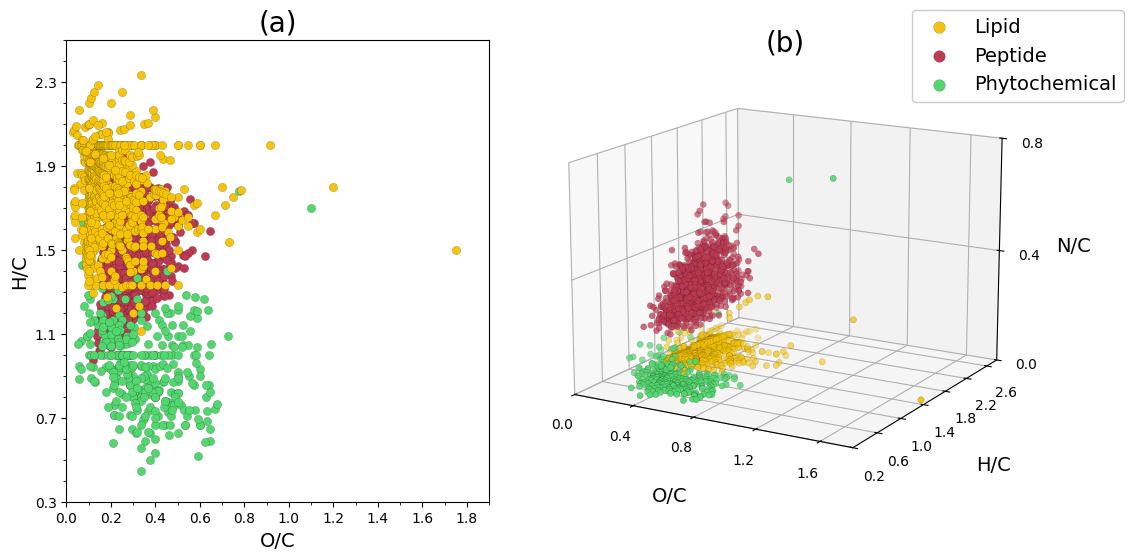

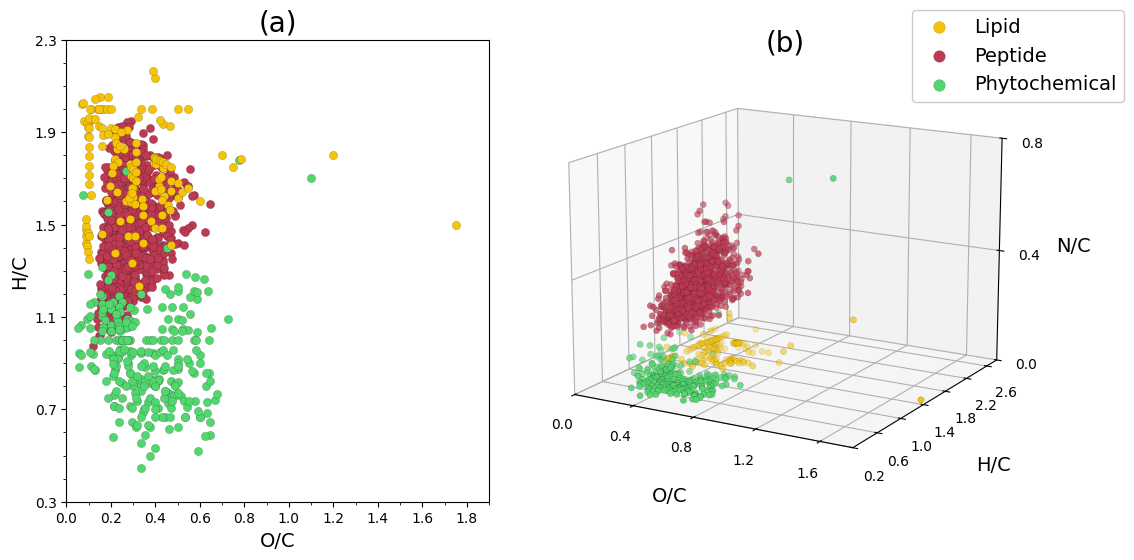

In [9]:
# Create Combined 2D and 3D Van Krevelen Diagram with PAHs
# Side-by-side comparison showing both perspectives

for combo in [[ru_test_df,'before'],
              [ru_test_df_cropped,'after']]:
    fig = plt.figure(figsize=(12, 6))

    # 2D Plot (subplot a)
    ax_2d = fig.add_subplot(121)

    for category in ['peptide','phytochemical','lipid',]:# 'peptide']:
        subset = combo[0][combo[0]['category'] == category]
        ax_2d.scatter(subset['O/C'], subset['H/C'],
                    c=mlcf.vk_region_colours[category],
                    edgecolor='k', lw=.1)

    ax_2d.set_xlabel('O/C', fontsize=14)
    ax_2d.set_ylabel('H/C', fontsize=14)

    mlcf.set_axis_ticks(combo[0]['O/C'].values, ax_2d, axis='x', major_ticks_interval=.2, minor_ticks_interval=.1, rounding=1, lower_lim=0)
    mlcf.set_axis_ticks(combo[0]['H/C'].values, ax_2d, axis='y', major_ticks_interval=.4, minor_ticks_interval=.1, rounding=1)

    # 3D Plot (subplot b)
    ax_3d = fig.add_subplot(122, projection='3d')

    ax_3d.scatter(combo[0]['O/C'], combo[0]['H/C'], combo[0]['N/C'],
                c=[mlcf.vk_region_colours[cat] for cat in combo[0]['category']],
                edgecolor='k', lw=.1)

    mlcf.set_axis_ticks(combo[0]['O/C'], ax_3d, axis='x', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1, lower_lim=min(0, 1.8), upper_lim=max(0, 1.8))
    mlcf.set_axis_ticks(combo[0]['H/C'], ax_3d, axis='y', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1, lower_lim=min(.2, 2.8), upper_lim=max(.2, 2.8))
    mlcf.set_axis_ticks(combo[0]['N/C'], ax_3d, axis='z', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1, lower_lim=min(0, .8), upper_lim=max(0, .8))

    # Create legend (shared between both plots)
    for cat in combo[0]['category'].unique():
        ax_3d.scatter(10, 10, 10, c=mlcf.vk_region_colours[cat], alpha=1, edgecolor='k', lw=.1,
                    label=cat.replace('_', ' ').capitalize() if cat != 'pah' else 'PAH',
                    s=70)
        
    ax_3d.legend(framealpha=1, bbox_to_anchor=(.8, .9), loc='lower left', borderaxespad=0, fontsize=14)
    ax_3d.view_init(elev=15, azim=-60)

    ax_3d.set_xlabel('O/C', fontsize=14, labelpad=15)
    ax_3d.set_ylabel('H/C', fontsize=14, labelpad=15)
    ax_3d.set_zlabel('N/C', fontsize=14, labelpad=8)

    ax_3d.set_box_aspect(None, zoom=1.15)

    # Add subplot labels
    ax_2d.set_title('(a)', fontsize=20)
    ax_3d.set_title('(b)', fontsize=20)

    fig.savefig(f'data\\plots\\van_krevelens\\vk_diagram_ru_validation_set_{combo[1]}.svg', dpi=600, facecolor='#fff', bbox_inches='tight')